In [1]:
from all_imports import * 

In [2]:
# ==========================================
# 1. ORDER ANOMALIES: Extreme Delivery Delays
# ==========================================
delivered_anomalies = orders_df[orders_df['order_status'] == 'delivered'].copy()
delivered_anomalies.dropna(subset=['order_delivered_customer_date', 'order_estimated_delivery_date'], inplace=True)

delivered_anomalies['order_delivered_customer_date'] = pd.to_datetime(delivered_anomalies['order_delivered_customer_date'])
delivered_anomalies['order_estimated_delivery_date'] = pd.to_datetime(delivered_anomalies['order_estimated_delivery_date'])

delivered_anomalies['delay_days'] = (
    delivered_anomalies['order_delivered_customer_date'] - 
    delivered_anomalies['order_estimated_delivery_date']
).dt.total_seconds() / (24 * 3600)

extreme_delays = delivered_anomalies[delivered_anomalies['delay_days'] > 30].sort_values('delay_days', ascending=False)


# ==========================================
# 2. SELLER ANOMALIES: Rogue Sellers (High Volume + Terrible Scores)
# ==========================================
item_reviews = orderItems_df[['order_id', 'seller_id', 'price']].merge(
    orderReviews_df[['order_id', 'review_score']], on='order_id', how='inner'
)

seller_anomaly_stats = item_reviews.groupby('seller_id').agg(
    order_count=('order_id', 'count'),
    avg_score=('review_score', 'mean'),
    total_revenue=('price', 'sum')
).reset_index()

rogue_sellers = seller_anomaly_stats[
    (seller_anomaly_stats['order_count'] >= 50) & 
    (seller_anomaly_stats['avg_score'] <= 2.0)
].sort_values('order_count', ascending=False)


# ==========================================
# 3. CATEGORY ANOMALIES: Pricing Outliers
# ==========================================
item_cat = orderItems_df.merge(products_df[['product_id', 'product_category_name']], on='product_id', how='left')
item_cat = item_cat.merge(productCategoryNameTranslation_df, on='product_category_name', how='left')

price_outliers = item_cat.groupby('product_category_name_english').agg(
    max_price=('price', 'max'),
    mean_price=('price', 'mean'),
    median_price=('price', 'median'),
    item_count=('price', 'count')
).reset_index().sort_values('max_price', ascending=False)

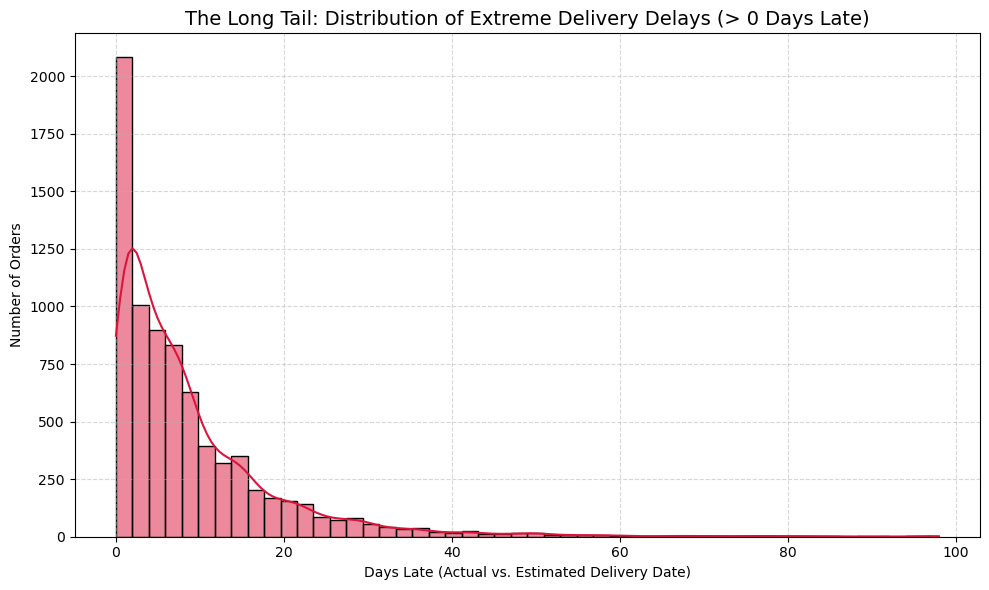

In [3]:
plt.figure(figsize=(10, 6))
plot_delays = delivered_anomalies[(delivered_anomalies['delay_days'] > 0) & (delivered_anomalies['delay_days'] <= 100)]
sns.histplot(plot_delays['delay_days'], bins=50, color='crimson', kde=True)
plt.title('The Long Tail: Distribution of Extreme Delivery Delays (> 0 Days Late)', fontsize=14)
plt.xlabel('Days Late (Actual vs. Estimated Delivery Date)')
plt.ylabel('Number of Orders')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

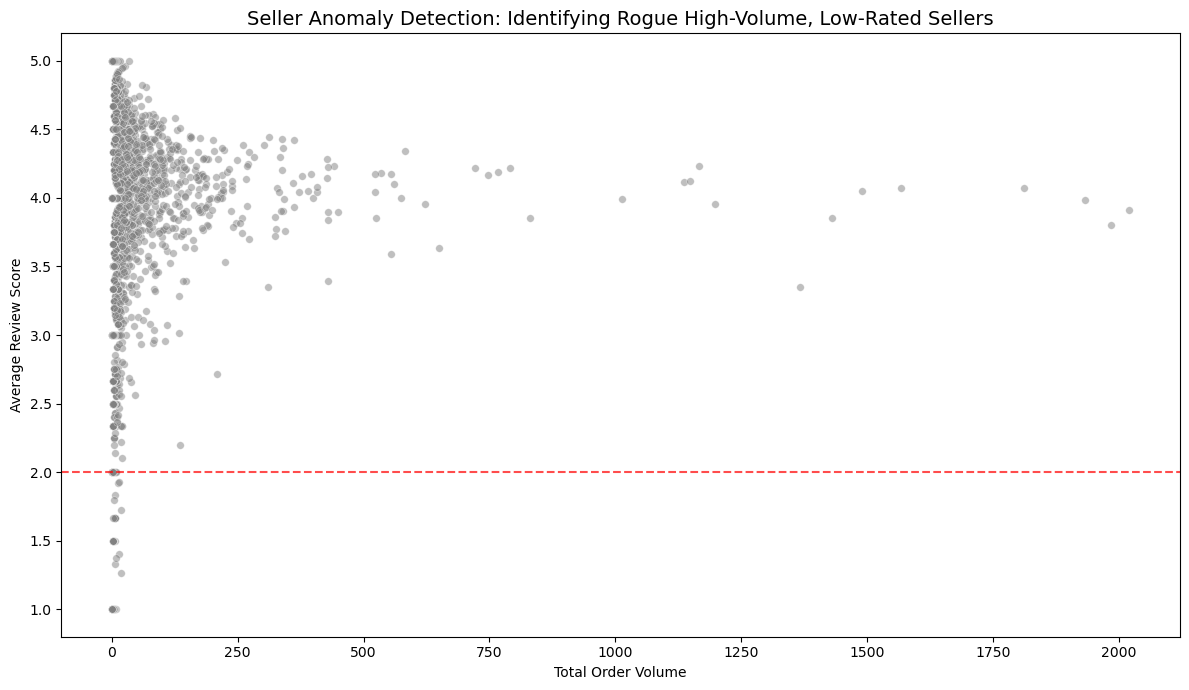

In [6]:
plt.figure(figsize=(12, 7))
sns.scatterplot(
    data=seller_anomaly_stats, 
    x='order_count', 
    y='avg_score', 
    alpha=0.5, 
    color='grey',
    s=30
)
sns.scatterplot(
    data=rogue_sellers, 
    x='order_count', 
    y='avg_score', 
    color='red',
    s=80,
    label='Rogue Sellers (>50 Orders, <2.0 Stars)'
)
plt.axhline(2.0, color='red', linestyle='--', alpha=0.7)
plt.title('Seller Anomaly Detection: Identifying Rogue High-Volume, Low-Rated Sellers', fontsize=14)
plt.xlabel('Total Order Volume')
plt.ylabel('Average Review Score')
plt.tight_layout()
plt.show()

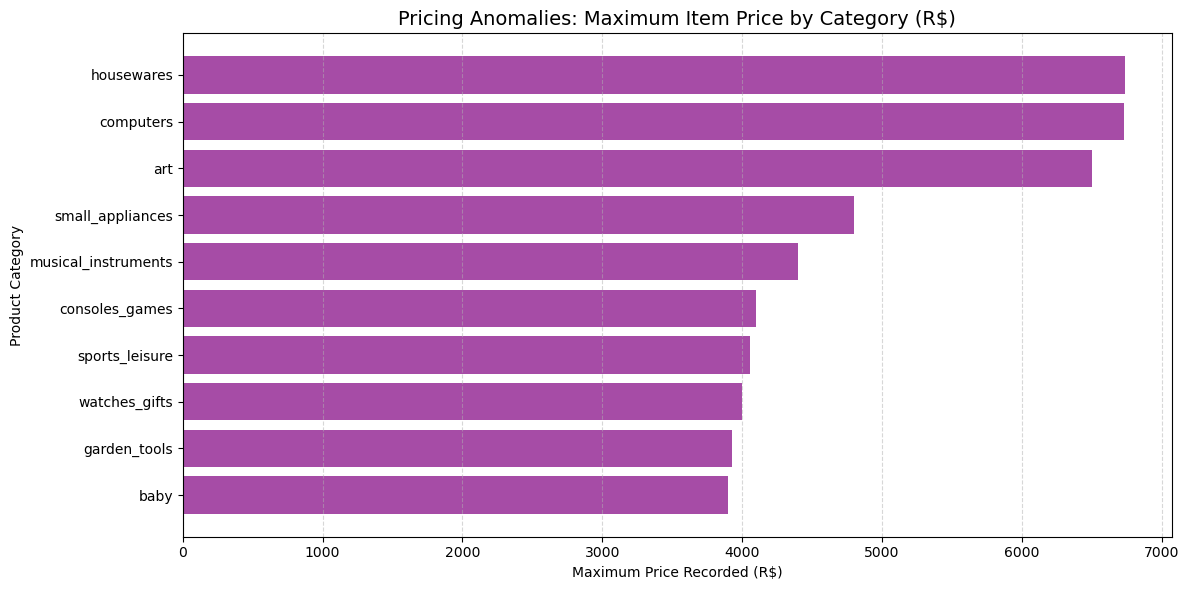

In [5]:
top_price_anomalies = price_outliers.head(10).sort_values('max_price', ascending=True)
plt.figure(figsize=(12, 6))
plt.barh(top_price_anomalies['product_category_name_english'], top_price_anomalies['max_price'], color='purple', alpha=0.7)
plt.title('Pricing Anomalies: Maximum Item Price by Category (R$)', fontsize=14)
plt.xlabel('Maximum Price Recorded (R$)')
plt.ylabel('Product Category')
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()